# Assignment 2: Netflix User Analytics

**Student Name:** Sadhika Rana

**Enrollment Number:** 17201012025

**College:** IGDTUW

---

This notebook contains data analysis and machine learning tasks performed on the Netflix User Analytics dataset using Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-Learn.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Part A: Dataset Understanding

## Q1. Load the dataset and display the first five records.

In [2]:
df = pd.read_csv("Dataset 2.csv")

df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


## Q2. Determine the number of rows and columns.

In [3]:
df.shape

(750, 10)

## Question 3: Determine the number of rows and columns.

In [4]:
df.columns

Index(['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek',
       'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend',
       'SubscriptionRenewed'],
      dtype='object')

## Question 4: Display information about the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   UserID               750 non-null    int64 
 1   Age                  750 non-null    int64 
 2   Gender               750 non-null    object
 3   SubscriptionType     750 non-null    object
 4   WatchHoursPerWeek    750 non-null    int64 
 5   DevicesUsed          750 non-null    int64 
 6   FavoriteGenre        750 non-null    object
 7   AdClicks             750 non-null    int64 
 8   MonthlySpend         750 non-null    int64 
 9   SubscriptionRenewed  750 non-null    object
dtypes: int64(6), object(4)
memory usage: 58.7+ KB


## Question 5: Generate descriptive statistics.

In [6]:
df.isnull().sum()

,0
UserID,0
Age,0
Gender,0
SubscriptionType,0
WatchHoursPerWeek,0
DevicesUsed,0
FavoriteGenre,0
AdClicks,0
MonthlySpend,0
SubscriptionRenewed,0


# Part B: Exploratory Data Analysis

## Question 6: Calculate the average age of users.

In [7]:
df["Age"].mean()

np.float64(41.824)

## Question 7: Determine the average watch hours per week.

In [8]:
df["WatchHoursPerWeek"].mean()

np.float64(14.236)

## Question 8: Find the average monthly spending of users.

In [9]:
df["MonthlySpend"].mean()

np.float64(689.9053333333334)

## Question 9: Count the number of users in each subscription category.


In [10]:
df["SubscriptionType"].value_counts()

,count
SubscriptionType,
Basic,342
Premium,279
VIP,129


## Question 10: Determine the percentage of users who renewed their subscriptions.

In [11]:
(df["SubscriptionRenewed"]=="Yes").mean()*100

np.float64(46.266666666666666)

# Part C: Data Preparation

## Question 11: Convert categorical features into numerical form.

In [12]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


## Question 12: Define the feature set (X) and target variable (y) for subscription renewal prediction.

In [13]:
X = df.drop("SubscriptionRenewed",axis=1)

y = df["SubscriptionRenewed"]

## Question 13: Split the dataset into training and testing sets.

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Part D: Decision Tree Classification

## Q14. Train a Decision Tree model to predict whether a user will renew their subscription.

In [15]:
dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

DecisionTreeClassifier()

## Q15. Evaluate the model using accuracy.

In [16]:
y_pred = dt.predict(X_test)

accuracy_score(y_test,y_pred)

0.56

## Q16. Generate and interpret the confusion matrix.

In [17]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[48 34]
 [32 36]]


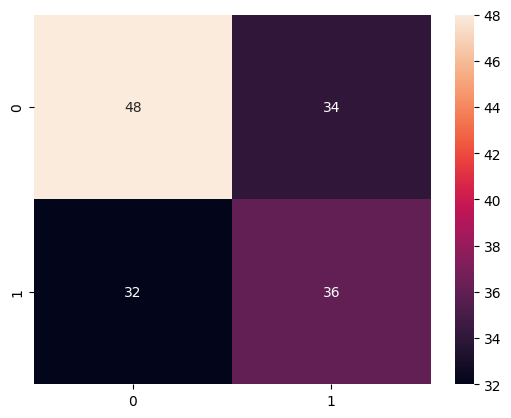

In [18]:
sns.heatmap(cm,annot=True)
plt.show()

# Part E: K-Nearest Neighbors (KNN)

## Q17. Train a KNN classifier with K = 5.

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

KNeighborsClassifier()

## Q18. Compare the accuracy of KNN with the Decision Tree model.

In [20]:
knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test,knn_pred)

print(knn_accuracy)

0.6


# Part F: Linear Regression

## Q19. Train a Linear Regression model to predict monthly spending.

In [21]:
X = df.drop("MonthlySpend",axis=1)

y = df["MonthlySpend"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

## Q20. Predict the monthly spending for a new user and interpret the result.

In [22]:
new_user = [1,25,1,2,20,2,3,5,1]

prediction = lr.predict([new_user])

print(prediction)

[1359.39773444]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Business Reflection Questions

## Question 1: Which factors appear to influence subscription renewal the most?

Based on the dataset analysis and machine learning models, factors such as subscription type, watch hours per week, monthly spending, user satisfaction, and content engagement appear to have a significant impact on subscription renewal. Users who actively use the platform and are satisfied with the service are more likely to renew their subscriptions.

## Question 2: Why is subscription renewal a classification problem?

Subscription renewal is a classification problem because the target variable has discrete outcomes. A user either renews the subscription or does not renew it. Machine learning models classify users into these categories based on their characteristics and usage patterns.

## Question 3: Why is monthly spending a regression problem?

Monthly spending is a regression problem because the target variable is a continuous numerical value. The model predicts the amount a user is likely to spend rather than assigning the user to a specific category.

## Question 4: Which algorithm performed better for renewal prediction?

The K-Nearest Neighbors (KNN) algorithm performed better than the Decision Tree classifier in this assignment.

- Decision Tree Accuracy: 56%
- KNN Accuracy: 60%

Since KNN achieved higher accuracy, it provided better predictions for subscription renewal on this dataset.

## Question 5: How could the platform use these predictions to improve customer retention?

The platform can use machine learning predictions to identify users who are less likely to renew their subscriptions. Special offers, personalized recommendations, discounts, and targeted marketing campaigns can be provided to these users to improve customer satisfaction and increase subscription renewal rates.

# Conclusion

In this assignment, Netflix user data was analyzed using Python and machine learning techniques. Exploratory data analysis provided insights into user behavior, while Decision Tree, KNN, and Linear Regression models were implemented for prediction tasks. Among the classification models, KNN achieved the best performance with an accuracy of 60%. The results demonstrate how data analytics and machine learning can help businesses understand customer behavior and improve decision-making.